<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Convolution, the idea behind CNNs</b>
</h1>
<div style="font-family:'Times New Roman';">
A normal neural net flattens the image into one long vector, so it throws away which pixel was next to which. A CNN doesnt do that. It slides a small filter over the image and keeps the 2d structure. This notebook is just about that one operation, convolution, becuase thats the whole heart of a CNN.
</div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

## what a kernel is

a kernel (or filter) is just a small grid of numbers. we put it on top of a patch of the image, multiply elementwise, add it all up, and thats one number in the output.

In [2]:
# a tiny 5x5 image and a 3x3 kernel, small numbers so we can follow along
image = np.array([
    [1, 2, 3, 0, 1],
    [0, 1, 2, 3, 1],
    [1, 2, 1, 0, 0],
    [5, 2, 3, 1, 1],
    [2, 1, 0, 1, 3]
])

kernel = np.array([
    [1, 1, 0],
    [0, 1, 1],
    [1, 0, 1]
])

print('image\n', image)
print('\nkernel\n', kernel)

image
 [[1 2 3 0 1]
 [0 1 2 3 1]
 [1 2 1 0 0]
 [5 2 3 1 1]
 [2 1 0 1 3]]

kernel
 [[1 1 0]
 [0 1 1]
 [1 0 1]]


## sliding it across

start top left, take a 3x3 patch, multiply by the kernel, sum. then move one step right and do it again, all the way across and down. the grid of sums is the **feature map**.

In [3]:
def convolve(image, kernel):
    h, w = image.shape
    k = kernel.shape[0]
    out = np.zeros((h - k + 1, w - k + 1))
    for i in range(h - k + 1):
        for j in range(w - k + 1):
            patch = image[i:i+k, j:j+k]
            out[i, j] = np.sum(patch * kernel)
    return out

feature_map = convolve(image, kernel)
print(feature_map)

[[ 8. 12.  8.]
 [12.  7.  9.]
 [10.  9.  6.]]


notice the output is 3x3, smaller than the 5x5 input. a 3x3 kernel eats one pixel off each side, so out size is `h - k + 1`. padding can fix that but i skipped it here.

In [4]:
# quick check on the shapes
print('in ', image.shape, ' kernel', kernel.shape, ' out', feature_map.shape)

in  (5, 5)  kernel (3, 3)  out (3, 3)


## same thing on a real image

different kernels pick up different things. these two are classic edge detectors, one for vertical edges and one for horizontal.

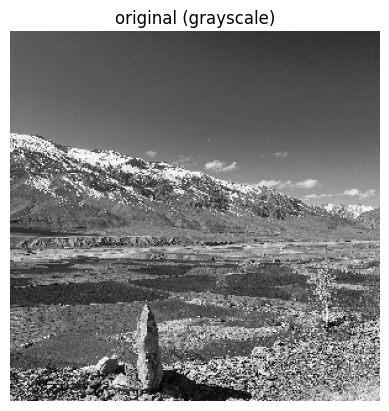

In [5]:
img = cv2.imread('image.jpeg', cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (300, 300))   # shrink it, the original is huge
plt.imshow(img, cmap='gray')
plt.title('original (grayscale)')
plt.axis('off')
plt.show()

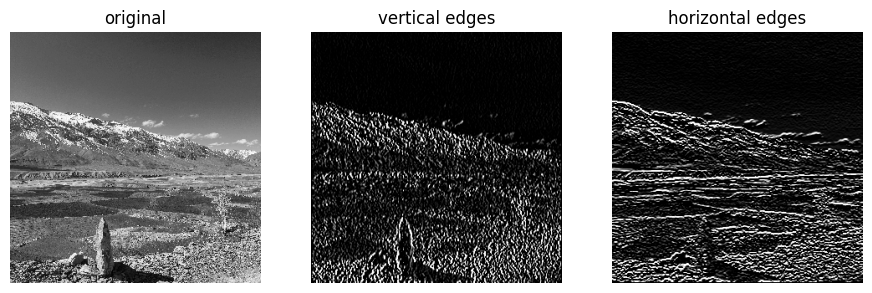

In [6]:
# sobel kernels, vertical and horizontal edges
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]])

edge_x = cv2.filter2D(img, -1, sobel_x)
edge_y = cv2.filter2D(img, -1, sobel_y)

fig, ax = plt.subplots(1, 3, figsize=(11, 4))
ax[0].imshow(img, cmap='gray');    ax[0].set_title('original')
ax[1].imshow(edge_x, cmap='gray'); ax[1].set_title('vertical edges')
ax[2].imshow(edge_y, cmap='gray'); ax[2].set_title('horizontal edges')
for a in ax: a.axis('off')
plt.show()

the vertical filter lights up the up and down edges, the horizontal one lights up the side to side edges. so one kernel = one kind of feature detector.

## why not just flatten the image

two reasons a CNN beats flattening into a dense net:
- flattening loses neighbourhood, the net no longer knows pixel (0,0) touches (0,1)
- the same small kernel slides over the whole image, so its way fewer weights and it can find a feature anywhere, not just where it saw it in training

### recap

convolution is just slide a small kernel, multiply, sum, repeat. stack a few learned kernels and the network builds up its own feature detectors. next i actually run a full forward pass through one by hand.